<a href="https://colab.research.google.com/github/wasimnawaz1/NLP_lectures/blob/main/Introduction_to_NLP_(Week_8)_Embeddings_CBOW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CS438  Natural Language Processing (NLP)** (Week 8)
https://github.com/wasimnawaz1/NLP_lectures

### Instructor: Dr. M. Wasim Nawaz (Associate Professor, Artificial Intelligence)
    📞+92-331-4180565  📧 wasim.nawaz@umt.edu.pk

Office: SST 1 - 506
Office Hours (Ramadan): 09:00 am to 10:00 am (Monday to Friday)

Office Hours: 10:00 am to 12:00 pm (Monday to Friday)



### This notebook revises basics of Neural Networks and then discusses Word Embeddings

### Biological Neurons

* **Dendrites**: Receive signals from other neurons.
* **Cell Body**: Processes the signals.
* **Axon**: Transmits the signal to other neurons.
* **Synapse**: Connection between neurons where signals are exchanged.

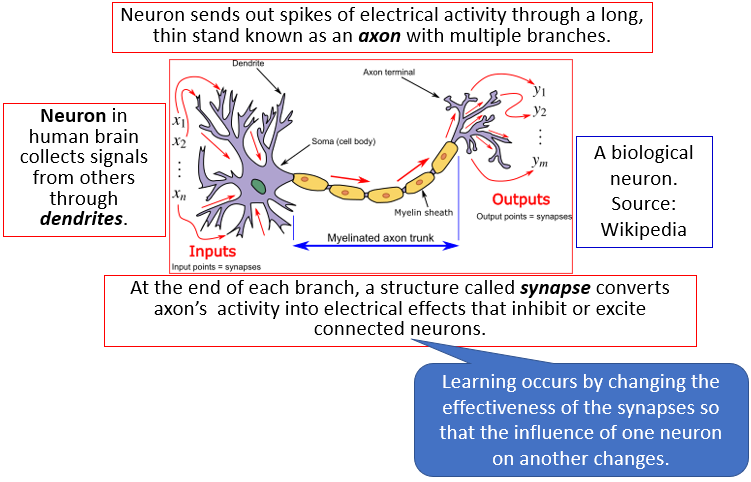

### Artificial Neuron: Building Block of Artificial Neural Networks (ANNs)

* Analogous to the biological structure where inputs are weighted, summed, and passed through an activation function.



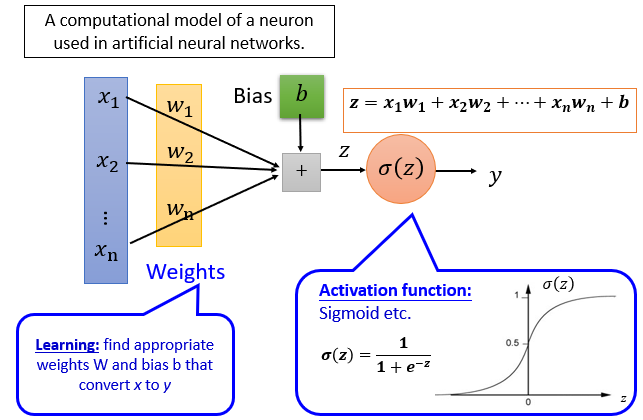



* **Mathematical Model**:
  * Inputs: $x_1, x_2, \dots, x_n$
  * Weights: $w_1, w_2, \dots, w_n$
  * Summation: $z = \sum_i (w_i x_i) + b$
  * Activation: $y = \sigma(z)$
* The activation function $\sigma(z)$ introduces non-linearity into the model.



### Multi-layer Neural Network


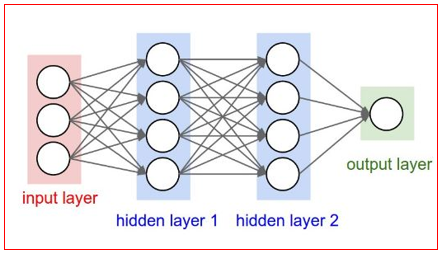




* **Input Layer**: Receives the input features.
* **Hidden Layers**: Layers between input and output that perform computations.
* **Output Layer**: Produces the final prediction.


> A **Deep** Neural Network is an ANN with many hidden layers.

### Forward Propagation in a Neural Network

Forward propagation is the process of calculating the output of the neural network from the input. Let:

* $L$: Total number of layers.
* $n^l$: Number of units in layer $l$.
* $w_{ij}^l$: Weight from unit $j$ in layer $l-1$ to unit $i$ in layer $l$.
* $b_i^l$: Bias of unit $i$ in layer $l$.
* $a_i^l$: Activation (output) of unit $i$ in layer $l$.

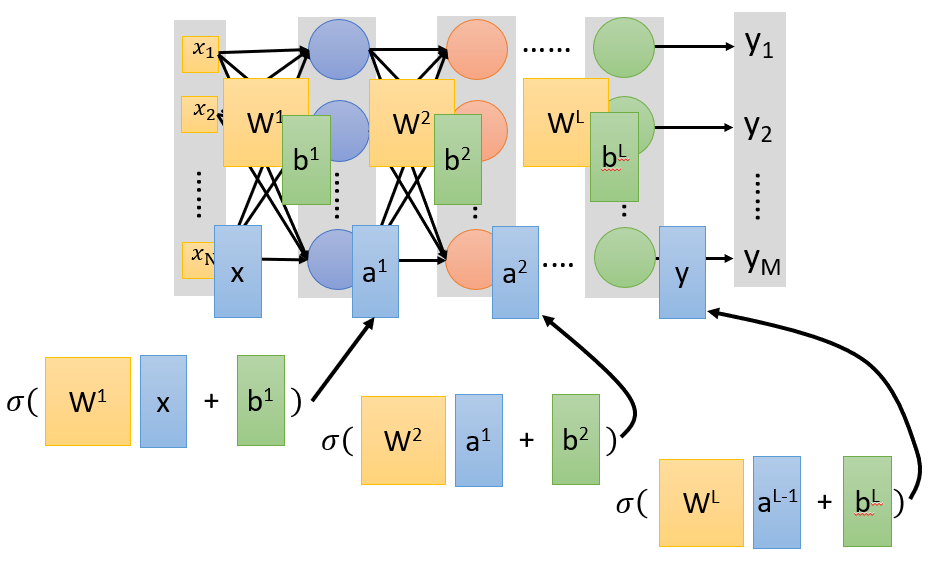


The forward propagation of input to the output is:


1. Start with input $a^0 = x$.
2. For each layer $l = 1, 2, \dots, L$:
   * Compute $z^l = W^l a^{l-1} + b^l$
   * Compute $a^l = \sigma(z^l)$
3. The final output is $\hat{y} = a^L$.





### Learning Network Parameters

* **Input**: $16 \times 16 = 256$ pixels.
* **Output**: $10$ classes (digit recognition).
* **Parameters**: $\theta = \{W^1, b^1, W^2, b^2, \dots, W^L, b^L\}$.
* **Goal**: Set the network parameters $\theta$ such that the predicted output $\hat{y}$ is as close as possible to the true label $y$.


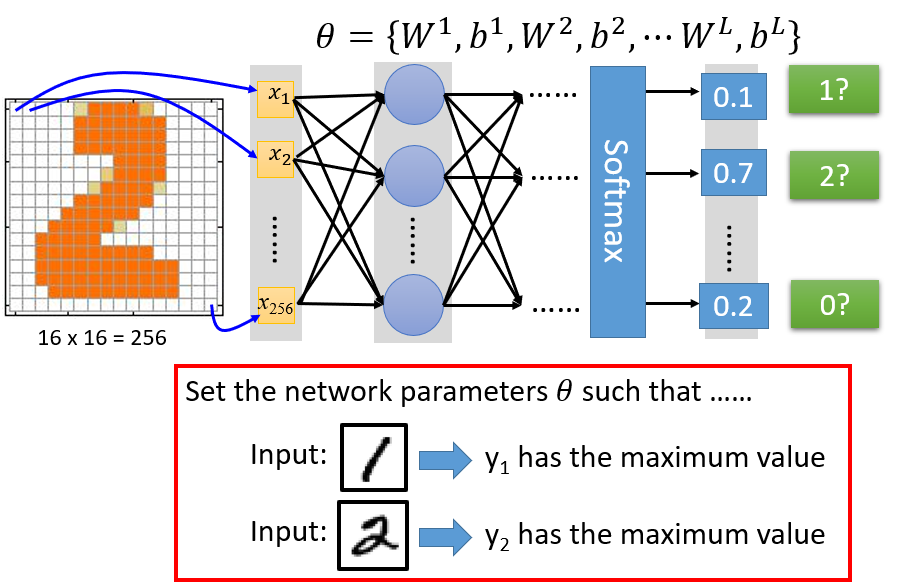

### Learning Network Parameters

* The **Loss Function** measures the error for a single training example.
* The **Cost Function** is the average of the loss functions over the entire training set.
* We want to find $\theta$ that minimizes the Cost Function $J(\theta)$.


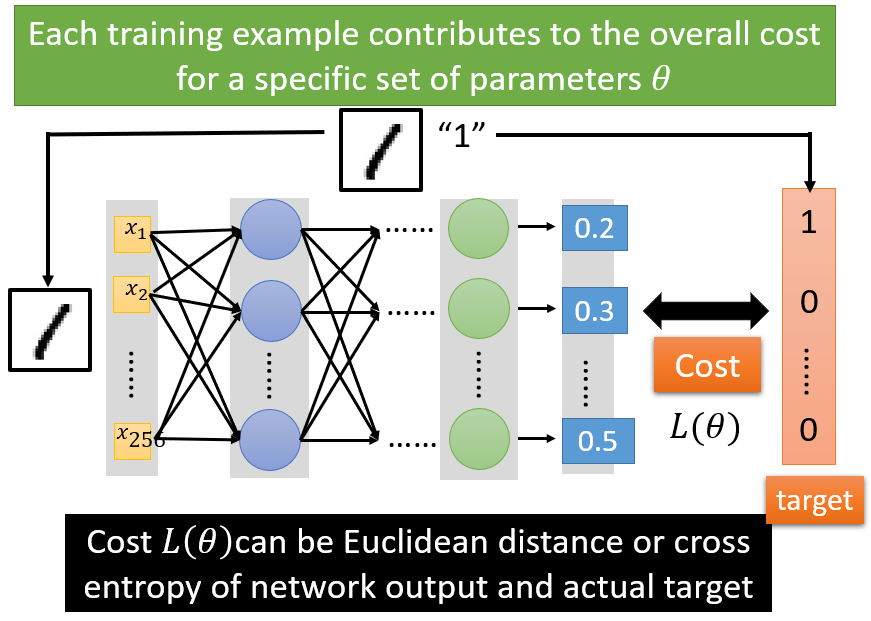


#### Mean Squared Error (MSE)
* Often used for regression problems.
* $L(\hat{y}, y) = \frac{1}{2} ||\hat{y} - y||^2$
* $J(W, b) = \frac{1}{m} \sum_{i=1}^{m} L(\hat{y}^{(i)}, y^{(i)})$

#### Cross-Entropy Loss

* Commonly used for classification problems.
* $L(\hat{y}, y) = - \sum y_i \log(\hat{y}_i)$
* It measures the performance of a classification model whose output is a probability value between 0 and 1.





### Learning Network Parameters

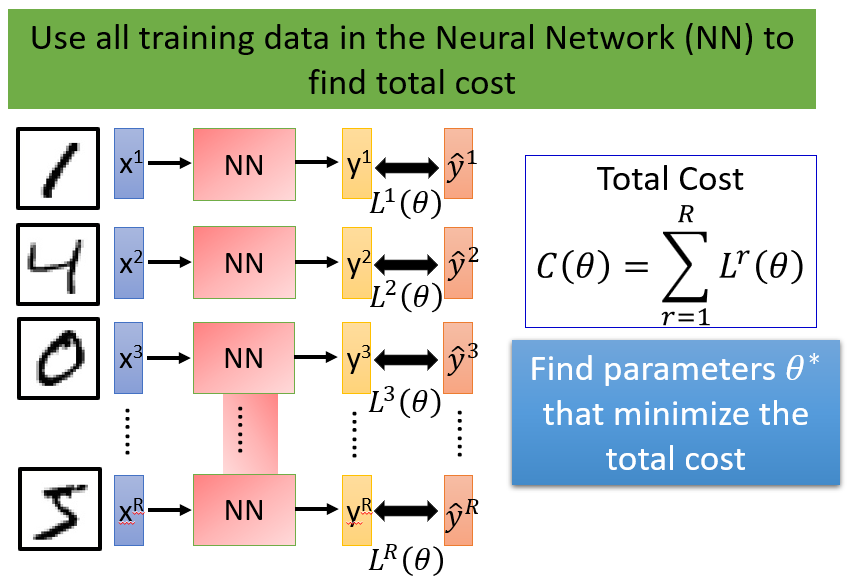

### Optimization: Gradient Descent Algorithm

* Algorithm to minimize the cost function $J(\theta)$.
* Update rule: $\theta = \theta - \alpha \frac{\partial J(\theta)}{\partial \theta}$
* $\alpha$ is the learning rate.
* The gradient $\frac{\partial J}{\partial \theta}$ points in the direction of the steepest increase; subtracting it moves us toward the minimum.

#### Backpropagation

* Method used to calculate the gradient of the loss function with respect to the weights in the network.
* It uses the **Chain Rule** from calculus.
* Error is propagated backwards from the output layer to the input layer to update weights.

### Deep Learning Architecture

Deep learning involves stacking many layers (Deep Neural Networks).
* For images, **Convolutional Neural Networks (CNNs)** are used to capture spatial hierarchies.
* For sequences, **Recurrent Neural Networks (RNNs)** are used.

#### Modern architectures
   * **Transformers**
   * State space models (SSMs) like **Mamba**

### This notebook covers Word Embeddings & Continuous Bag-of-Words (CBOW) Model to Learn Word Embeddings

#### Learning objectives
- Identify the key concepts of word representations
- Generate word embeddings
- Prepare text for machine / deep learning
- Implement the CBOW model

> **Prerequisite: neural networks**

### Applications of Word Embeddings

Word embeddings power a wide range of NLP tasks:


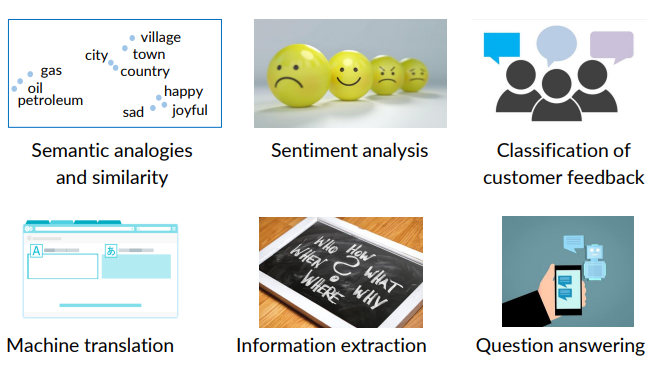

Words that share meaning or context end up **close together** in the embedding space (e.g. *gas, oil, petroleum* cluster near each other).


### Basic Word Representations

There are three main ways to represent a word as a number or vector:

1. **Integers** — assign each word a unique index  
2. **One-hot vectors** — a sparse binary vector with a single `1` at one location only
3. **Word embeddings** — dense, low-dimensional, meaning-rich vectors  


### Integer Representation

Every word is mapped to a unique integer.

| Word | Number |
|------|--------|
| a | 1 |
| able | 2 |
| about | 3 |
| … | … |
| hand | 615 |
| happy | 621 |
| zebra | 1000 |

✅ **Simple**  
❌ **Implied ordering** — the model may incorrectly infer `hand < happy < zebra`, which carries no semantic meaning.


### One-hot Vectors

Each word becomes a vector of length **V** (vocabulary size) with a `1` at the word's index and `0` everywhere else.

```
"happy" → [0, 0, ..., 1, ..., 0]   (1 at position 621, 0 elsewhere)
```

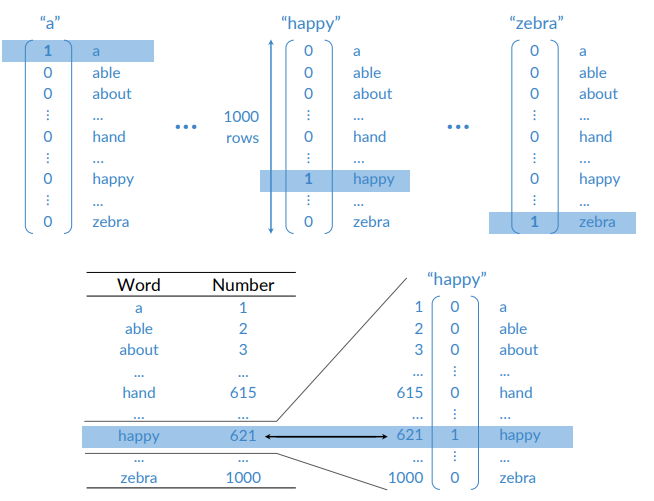

✅ **Simple** — no implied ordering  
❌ **Huge sparse vectors** — vocab can be 10 k–1 M words  
❌ **All dis-similar vectors (dot product)**


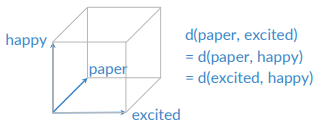

### Cosine Similarity

A standard metric to measure how **close** two word vectors are:

$$\text{Cosine Similarity}(u, v) = \frac{u \cdot v}{\|u\|\, \|v\|}$$

- $1.0$ → identical direction (very similar)  
- $0.0$ → orthogonal (unrelated)  
- $-1.0$ → opposite directions  


### Word Embedding Vectors

Words are represented as **dense, low-dimensional** vectors (~100–1000 dimensions) where word position encodes meaning.



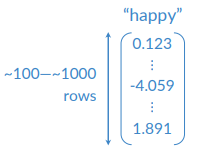


✅ **Low dimension** — far more compact than one-hot  
✅ **Embeds meaning** — semantically similar words are geometrically close  
  - `forest ≈ tree`  (nearby in embedding space)  
  - `forest ≉ ticket` (far apart)  

> **Terminology note:**  "word vectors", "word embeddings", and "word embedding vectors" all refer to the same thing.


### How Word Embeddings Are Created

The pipeline for learning word embeddings:


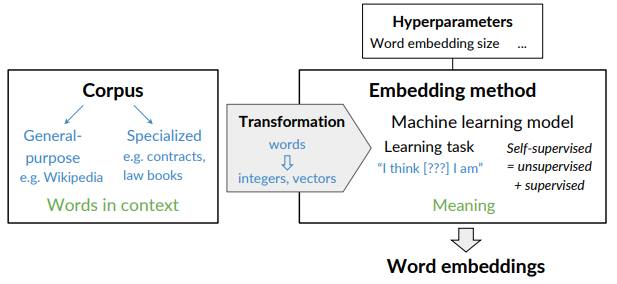

**Key choices:**
- **Corpus** — general-purpose (Wikipedia) or domain-specific (legal, medical)  
- **Embedding method** — defines the architecture and learning task (classification, etc.)
- **Hyperparameters** — embedding size $N$, learning rate, window size $C$, etc.

> The learning is **self-supervised**: labels are generated automatically from the corpus itself (no human annotation needed).


### Some Word Embedding Methods

| Method                          | Author                 | Year |          |
| ------------------------------- | ---------------------- | ---- | ---------------- |
| **word2vec** (CBOW & Skip-gram) | Google                 | 2013 |
| **GloVe** (Global Vectors)      | Stanford University    | 2014 |
| **fastText**                    | Meta Platforms         | 2016 |
| **ELMo**                        | Allen Institute for AI | 2018 |
| **BERT**                        | Google                 | 2018 |
| **GPT-2**                       | OpenAI                 | 2018 |


### Continuous Bag-of-Words (CBOW) Model

CBOW is one of the two architectures in **word2vec** (Mikolov et al., 2013).
[Efficient Estimation of Word Representations in Vector Space](https://arxiv.org/abs/1301.3781)

- Given the **surrounding context words**, predict the **center word**.


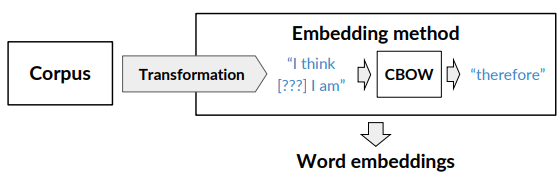


```
"The little  ___?___  is barking"
              ↓
          dog / puppy / hound / terrier …
```

- The model learns to make good predictions, and the learned neural network weights become word embeddings.


> **Note:** Another embedding model, Skip-Gram, in contrast to CBOW, uses a single input word to predict the surrounding context words. (*Accurate but computationally more expensive*.)

### CBOW Context Window

**Example**: Context half-size $C$ = 2 and Window size= $5$.


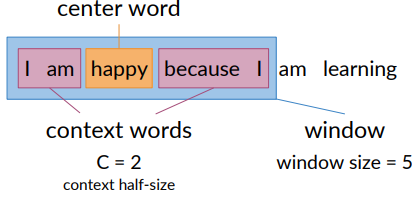

For each position in the corpus, we define:

- **Center word** — the word we want to predict  
- **Context words** — the C words to the left and C words to the right  
- **Window size** = 2C + 1 (total words in the window)  



### CBOW Generating Training Examples (Sliding Window)

We slide the window across the entire corpus to create (context words → center word) training pairs:

| Context words | Center word |
|---|---|
| I, am, because, I | **happy** |
| am, happy, I, am | **because** |
| happy, because, am, learning | **I** |


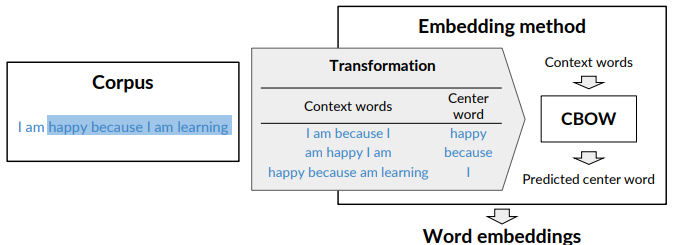




> Each training example = one step of the sliding window.


### Transforming Words into Vectors

#### One-hot Encoding of Center Words

Build a vocabulary, then represent each word as a one-hot vector.

**Vocabulary** (from example corpus): `am, because, happy, I, learning`  (V = 5)

```
am       → [1, 0, 0, 0, 0]
because  → [0, 1, 0, 0, 0]
happy    → [0, 0, 1, 0, 0]
I        → [0, 0, 0, 1, 0]
learning → [0, 0, 0, 0, 1]
```


### Averaging One-hot Vectors for Context Words

For each training example, the CBOW input vector is the **mean** of the one-hot vectors of all context words.

**Example** — context = [I, am, because, I]:

```
I        → [0, 0, 0, 1, 0]
am       → [1, 0, 0, 0, 0]
because  → [0, 1, 0, 0, 0]
I        → [0, 0, 0, 1, 0]
──────────────────────────────  sum then / 4
mean     → [0.25, 0.25, 0, 0.5, 0]
```

- This averaged vector is fed as input **x** to the neural network.


#### **Final prepared training set**


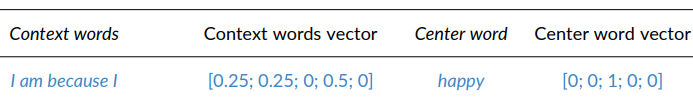


### CBOW Neural Network Architecture


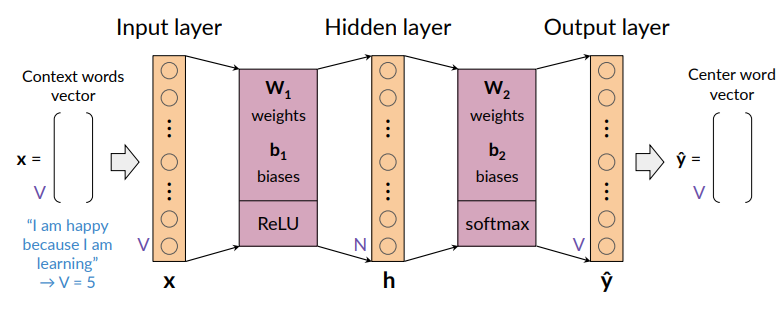

| Symbol | Meaning |
|--------|---------|
| $V$ | Vocabulary size |
| $N$ | **Word embedding size** (hyperparameter, e.g. 100–300) |
| $m$ | Batch size |
| $W_1$ | Weight matrix, shape $N × V$ |
| $b_1$| Bias vector, shape $N × 1$ |
| $W_2$ | Weight matrix, shape $V × N$ |
| $b_2$ | Bias vector, shape $V × 1$ |




### CBOW Neural Network Architecture (Single Input)

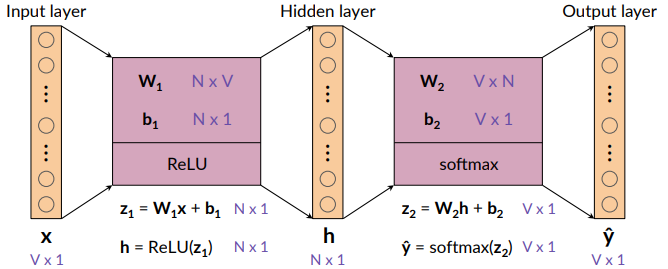



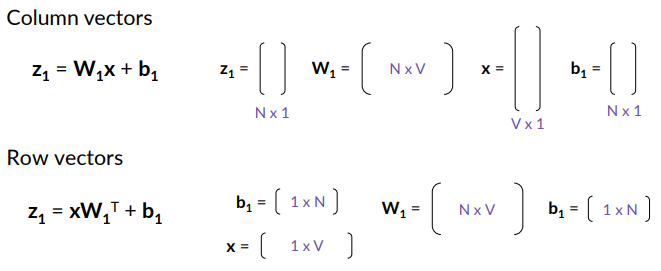


### CBOW Neural Network Architecture (Batch Input)

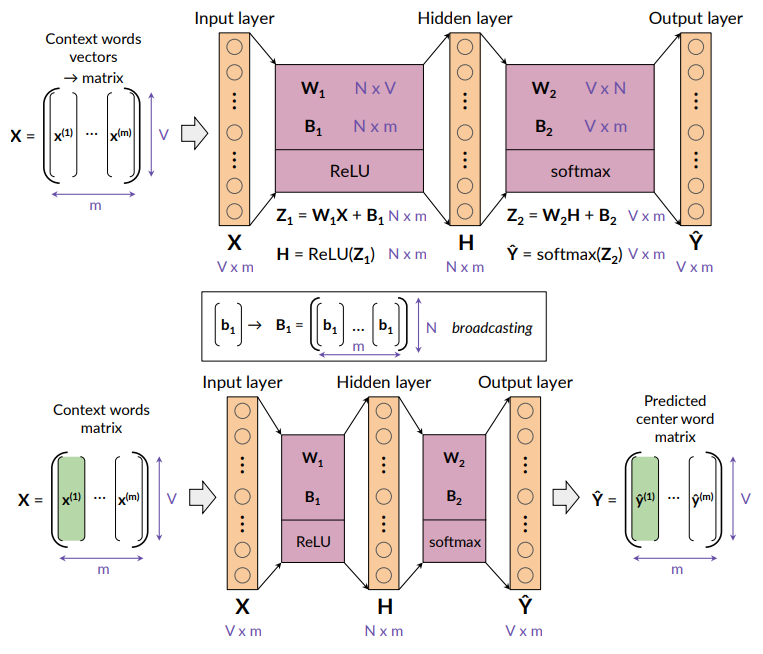

### CBOW Neural Network Architecture (Activation Function: ReLU)

$$\text{ReLU}(x) = \max(0,\, x)$$

- Negative values → **0** (zeroed out)  
- Positive values → **passed through unchanged**  

**Example:**
```
z₁ = [5.1, -0.3, …, -4.6, 0.2]
h   = [5.1,  0.0, …,  0.0, 0.2]   ← ReLU applied element-wise
```


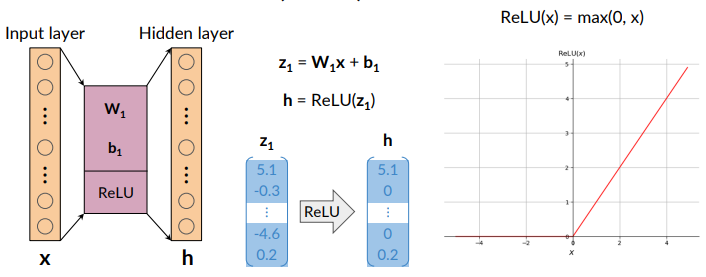





### CBOW Neural Network Architecture (Output Activation: Softmax)

$$\hat{y}_i = \frac{e^{z_i}}{\sum_{j=1}^{V} e^{z_j}}$$

- Converts raw logits into a **probability distribution** over the vocabulary  
- All outputs ∈ [0, 1] and sum to 1  
- The index with the highest value is the **predicted center word**


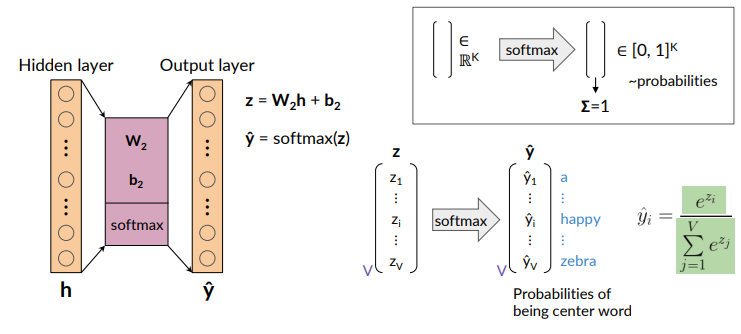


**Example** ($V$ = 5):


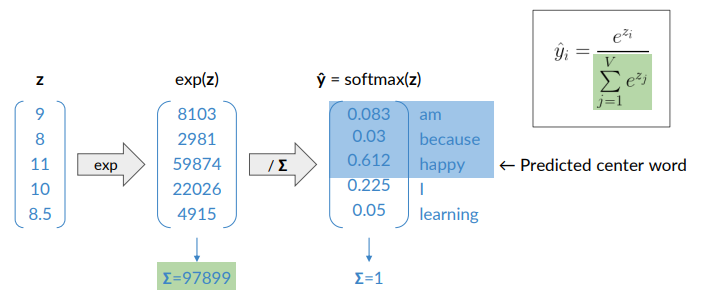



### Batch Processing (Vectorized)

For a batch of $m$ training examples, inputs/outputs become matrices:

| Symbol  | Shape | Description |
|--------|-------|-------------|
| $X$ | $V × m$ | Context word vectors (one column per example) |
| $Z_1 = W_1X + B_1$ | $N × m$ | Pre-activation hidden layer |
| $H$ = $\text{ReLU}(Z_1)$ | $N × m$ | Hidden layer activations |
| $Z_2 = W_2H + B_2$ | $V × m$ | Pre-activation output layer |
| $\hat{Y} = \text{softmax}(Z_2)$ | $V × m$ | Predicted probability distributions |
| Y | V × m | True one-hot center word vectors |


Note: $B_1$ is the column-broadcast of bias $b_1$ (repeated $m$ times).

- In NumPy this is handled automatically via **broadcasting**.


### Cost Function: Cross-Entropy Loss


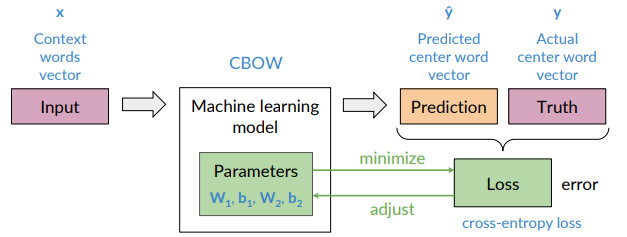



### Cost Function: Cross-Entropy Loss

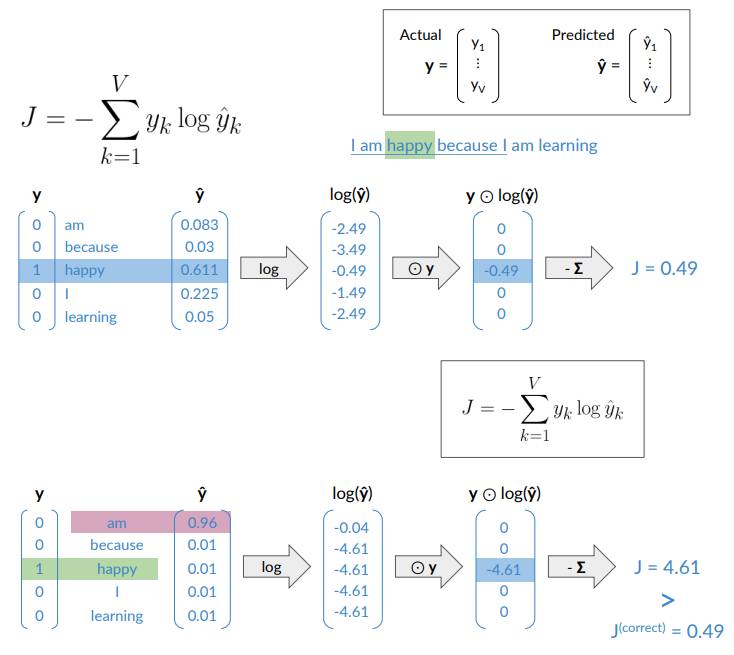


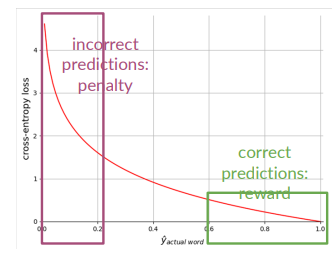

### Training a CBOW Model

Training process
- Forward propagation
- Cost
- Backpropagation and gradient descent


#### Forward propagation
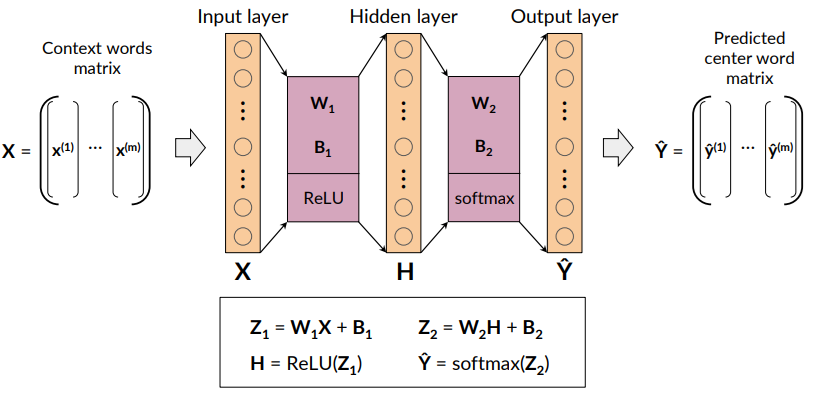

### Training a CBOW Model for $V$ Classes

#### Cost

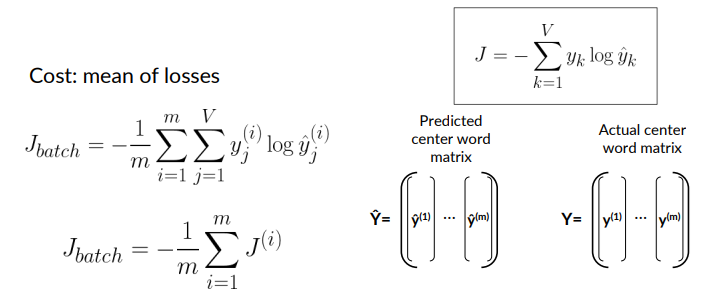


### Training a CBOW Model

#### Backpropagation & Gradient Descent

- **Minimizing the cost**: $J_{batch}= f(W_1, W_2, b_1, b_2)$

- **Backpropagation**: calculate partial derivatives of cost with respect to weights and biases

- **Gradient descent**: update weights and biases


Using learning rate $\alpha$ for gradient descent update:

$$W_1 := W_1 - \alpha \frac{\partial J_{batch}}{\partial W_1}$$
$$W_2 := W_2 - \alpha \frac{\partial J_{batch}}{\partial W_2}$$
$$b_1 := b_1 - \alpha \frac{\partial J_{batch}}{\partial b_1}$$
$$b_2 := b_2 - \alpha \frac{\partial J_{batch}}{\partial b_2}$$

Repeat the process
            
    forward pass → cost calculation → backward pass (backpropagation) → update until convergence.


### Extracting Word Embedding Vectors
After training, word embeddings can be extracted in **three ways**:

| Option | How | Shape |
|--------|-----|-------|
| **Option 1** | Columns of $W_1$ | Each column = embedding for one word |
| **Option 2** | Rows of $W_2$ | Each row = embedding for one word |
| **Option 3** | Average: $0.5 * (W_1 + W_2^T)$ | Combines both sources |

All three options produce an $N × V$ embedding matrix where each column is the embedding vector for one word.

- Option 1

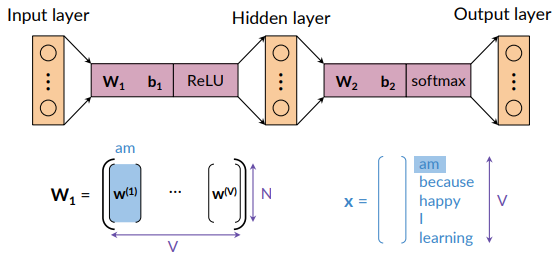



- Option 2


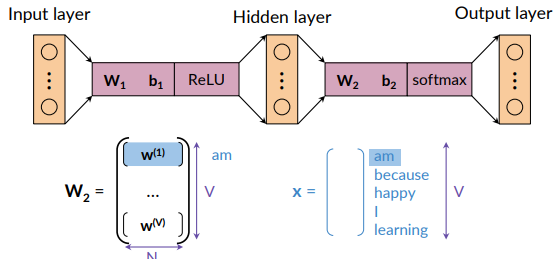





- Option 3


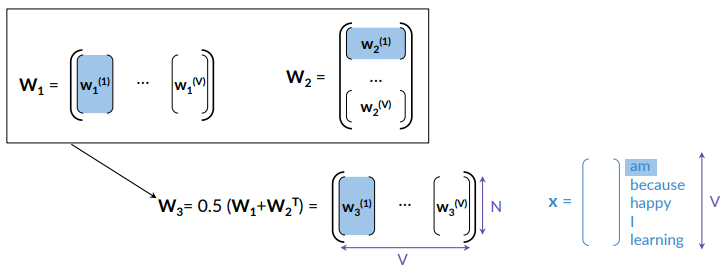





### Evaluating Word  Embeddings

#### Intrinsic Evaluation
- Tests the **internal quality** of embeddings directly by checking the relationships between words:
| Method | Description |
|--------|-------------|
| **Analogies** | "France : Paris :: Italy : ?" → check if model returns *Rome* |
| **Clustering** | Do semantically related words cluster together? |
| **Visualization** | t-SNE or PCA plot to visually inspect clusters |

- **Exrinsic evaluation** tests word embeddings on external tasks, e.g. named entity recognition, parts-of-speech tagging, etc.

### Evaluating Word  Embeddings

#### Intrinsic Evaluation (Analogies)

- **Semantic analogy:** "France" is to "Paris" as "Italy" is to `?`  (→ *Rome*)
- **Syntactic analogy:** "seen" is to "saw" as "been" is to `?` (→ *was*)
  


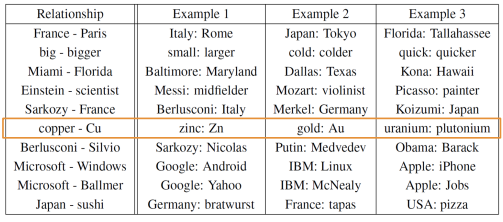

### Evaluating Word  Embeddings

- Intrinsic evaluation (**Clustering**)

> Michael Zhai, Johnny Tan, and Jinho
D. Choi. 2016. [Intrinsic and extrinsic
evaluations of word embeddings](https://ojs.aaai.org/index.php/AAAI/article/view/9959)


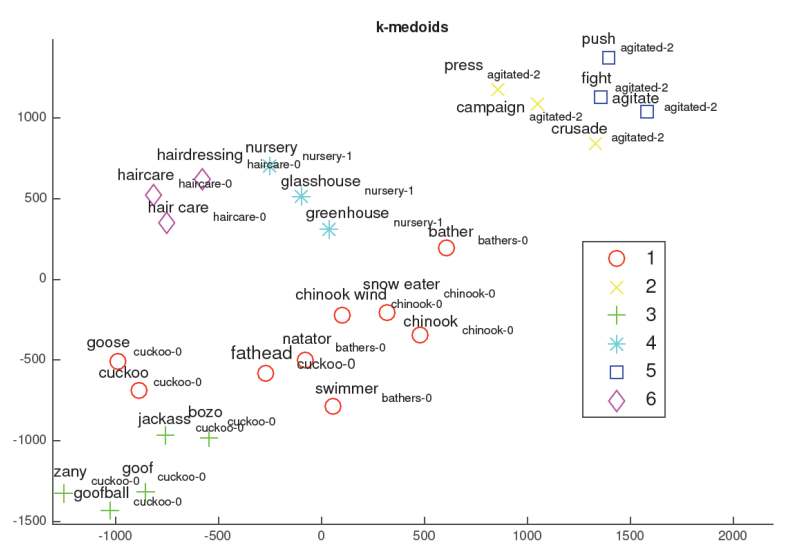


> K-Medoids, also known as Partitioning Around Medoids (PAM), is similar to K-Means clustering, but instead of using the mean of points as a cluster center, it uses an actual data point called a medoid.

### Evaluating Word  Embeddings

#### **Exrinsic evaluation**
- Tests word embeddings on external **real downstream NLP tasks**:
    - Named entity recognition
    - Part-of-speech tagging  
    - Machine translation quality  

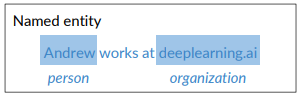


-  **Evaluates true usefulness** of the embeddings for applications  
-  **Time-consuming** to set up and train downstream model  
-  **Harder to troubleshoot** — poor results could be model, data, or embeddings


### Summary

| Concept | Key Takeaway |
|---------|-------------|
| **Integer encoding** | Simple but implies meaningless ordering |
| **One-hot vectors** | No ordering, but huge & no semantic info |
| **Word embeddings** | Dense, low-dim, encode meaning geometrically |
| **CBOW task** | Predict center word from context words |
| **Context window** | Half-size $C$ controls how many neighbors are used |
| **Text cleaning** | Lowercase, normalize punctuation, handle numbers/emoji |
| **Network** | Input($V$) → ReLU hidden($N$) → Softmax output($V$) |
| **Loss** | Cross-entropy: penalizes wrong predictions heavily |
| **Training** | Forward → cost → backprop → gradient descent |
| **Embedding extraction** | Use $W_1$ columns, $W_2$ rows, or their average |
| **Intrinsic eval** | Analogies, clustering, visualization |
| **Extrinsic eval** | Downstream NLP task performance |

> **Reference:** Mikolov, T., Chen, K., Corrado, G.S., & Dean, J. (2013).
[*Efficient Estimation of Word Representations in Vector Space*](https://arxiv.org/abs/1301.3781).


### Text Cleaning & Tokenization

Before building training data for any embedding model, the raw corpus must be cleaned:

| Issue | Example | Treatment |
|---|---|---|
| Letter case | `"The"`, `"the"`, `"THE"` | Lowercase all |
| Punctuation | `!`, `?`, `,` | Normalize to `.` or remove |
| Quotes | `"`, `'`, `«` | Remove |
| Numbers | `1`, `2`, `2020` | Remove or replace with `<NUMBER>` |
| Special chars | `∇`, `$`, `€` | Remove |
| Emoji/hashtags | 😊, `#nlp` | Keep as tokens (`:happy:`, `#nlp`) |



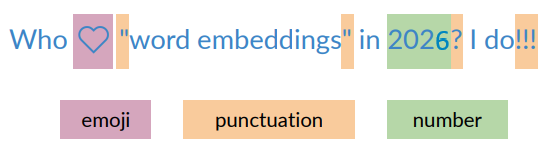

### Training a CBOW Model

#### Backpropagation & Gradient Descent

- **Minimizing the cost**: $J_{batch}= f(W_1, W_2, b_1, b_2)$

- **Backpropagation**: calculate partial derivatives of cost with respect to weights and biases

- **Gradient descent**: update weights and biases


**Gradients** wrt to weights and biases:
$$\frac{\partial J_{batch}}{\partial W_1} = \frac{1}{m} W_2^T(\hat{Y} - Y) \cdot \text{step}(Z_1) \cdot X^T$$

$$\frac{\partial J_{batch}}{\partial b_1} = \frac{1}{m} W_2^T(\hat{Y} - Y) \cdot \text{step}(Z_1) \cdot \mathbf{1}_m^T$$

$$\frac{\partial J_{batch}}{\partial W_2} = \frac{1}{m}(\hat{Y} - Y)H^T$$

$$\frac{\partial J_{batch}}{\partial b_2} = \frac{1}{m}(\hat{Y} - Y)\mathbf{1}_m^T$$

where $\text{step}(Z_1)$ is the derivative of ReLU (= 1 where $Z_1 > 0$, else $0$), and $\mathbf{1}_m = [1, 1, …, 1]$ (length $m$).

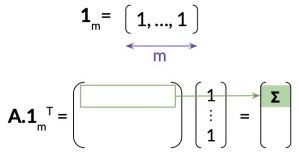

### Training a CBOW Model

#### Gradient Descent Update

Using learning rate $\alpha$:

$$W_1 := W_1 - \alpha \frac{\partial J_{batch}}{\partial W_1}$$
$$W_2 := W_2 - \alpha \frac{\partial J_{batch}}{\partial W_2}$$
$$b_1 := b_1 - \alpha \frac{\partial J_{batch}}{\partial b_1}$$
$$b_2 := b_2 - \alpha \frac{\partial J_{batch}}{\partial b_2}$$

Repeat the process
            
    forward pass → cost → backward pass → update until convergence.


In [ ]:
# ── Dependencies ──────────────────────────────────────────────────────────
# pip install nltk emoji

import re
import nltk
nltk.download('punkt_tab')  # run once

# ── Sample corpus ─────────────────────────────────────────────────────────────
corpus = 'Who ❤ "word embeddings" in 2020? I do!!!'
print("Original:", corpus)

# Step 1: Normalize punctuation → single dot
data = re.sub(r'[,!?;-]+', '.', corpus)
print("After punct normalization:", data)

# Step 2: Tokenize
data = nltk.word_tokenize(data)
print("After tokenization:", data)

# Step 3: Lowercase + keep only alpha tokens, dots, and emoji
import unicodedata

def is_emoji(ch):
    # Simple check: characters outside Basic Multilingual Plane
    # (Symbol Other ('So') - Symbol Math ('Sm') Unicode categories)
    try:
        return unicodedata.category(ch) in ('So', 'Sm')
    except:
        return False

data = [ch.lower() for ch in data
        if ch.isalpha() or ch == '.' or is_emoji(ch)]
print("Final cleaned tokens:", data)


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Original: Who ❤ "word embeddings" in 2020? I do!!!
After punct normalization: Who ❤ "word embeddings" in 2020. I do.
After tokenization: ['Who', '❤', '``', 'word', 'embeddings', "''", 'in', '2020', '.', 'I', 'do', '.']
Final cleaned tokens: ['who', '❤', 'word', 'embeddings', 'in', '.', 'i', 'do', '.']


In [ ]:
# ── Sliding window generator ──────────────────────────────────────────────

def get_windows(words, C):
    """
    Yield (context_words, center_word) pairs using a window of half-size C.

    Parameters
    ----------
    words : list[str]  tokenized sentence
    C     : int        context half-size (words on each side of center)
    """
    i = C
    while i < len(words) - C:
        center_word  = words[i]
        context_words = words[(i - C):i] + words[(i + 1):(i + C + 1)]
        yield context_words, center_word
        i += 1

# Demo
sentence = ['i', 'am', 'happy', 'because', 'i', 'am', 'learning']
print(f"{'Context words':<40} {'Center word'}")
print("-" * 55)
for ctx, ctr in get_windows(sentence, C=2):
    print(f"{str(ctx):<40} {ctr}")


Context words                            Center word
-------------------------------------------------------
['i', 'am', 'because', 'i']              happy
['am', 'happy', 'i', 'am']               because
['happy', 'because', 'am', 'learning']   i


In [ ]:
import numpy as np

# ── Vocabulary ────────────────────────────────────────────────────────────────
corpus_words = ['i', 'am', 'happy', 'because', 'i', 'am', 'learning']
vocab = sorted(set(corpus_words))          # ['am','because','happy','i','learning']
word2idx = {w: i for i, w in enumerate(vocab)}
V = len(vocab)
print("Vocabulary:", vocab)
print("V =", V)

# ── Helper: word → one-hot ────────────────────────────────────────────────────
def word_to_onehot(word, word2idx, V):
    vec = np.zeros(V)
    vec[word2idx[word]] = 1
    return vec

# ── Helper: context list → averaged vector ───────────────────────────────────
def context_to_vector(context_words, word2idx, V):
    return np.mean([word_to_onehot(w, word2idx, V) for w in context_words], axis=0)

# ── Build dataset ─────────────────────────────────────────────────────────────
X_list, Y_list = [], []
for ctx, ctr in get_windows(corpus_words, C=2):
    X_list.append(context_to_vector(ctx, word2idx, V))
    Y_list.append(word_to_onehot(ctr, word2idx, V))

X = np.column_stack(X_list)   # shape: (V, m)
Y = np.column_stack(Y_list)   # shape: (V, m)
m = X.shape[1]
print(f"\nX shape: {X.shape}  (V={V}, m={m} training examples)")
print(f"Y shape: {Y.shape}")
print("\nContext vectors (columns of X):")
print(np.round(X, 2))


Vocabulary: ['am', 'because', 'happy', 'i', 'learning']
V = 5

X shape: (5, 3)  (V=5, m=3 training examples)
Y shape: (5, 3)

Context vectors (columns of X):
[[0.25 0.5  0.25]
 [0.25 0.   0.25]
 [0.   0.25 0.25]
 [0.5  0.25 0.  ]
 [0.   0.   0.25]]


### Using Pre-trained Embeddings in Keras / PyTorch

In practice, you rarely train embeddings from scratch on a small corpus.  
Instead, use **pre-trained** embeddings (GloVe, word2vec, fastText) or let a framework learn them:

```python
# ── Keras ──────────────────────────────────────────────────────────────────
from keras.layers import Embedding
embed_layer = Embedding(input_dim=10000,   # vocab size
                        output_dim=400)    # embedding dimension

# ── PyTorch ─────────────────────────────────────────────────────────────────
import torch.nn as nn
embed_layer = nn.Embedding(num_embeddings=10000,
                           embedding_dim=400)
```

Both create a learnable **lookup table** of shape `(vocab_size, embedding_dim)`.


### Full CBOW Implementation in NumPy


In [ ]:
import numpy as np

# ─── Activation functions ──────────────────────────────────────────────────

def relu(z):
    return np.maximum(0, z)

def softmax(z):
    e = np.exp(z - z.max(axis=0, keepdims=True))  # numerically stable
    return e / e.sum(axis=0, keepdims=True)

# ─── Forward pass ──────────────────────────────────────────────────────────

def forward(X, W1, b1, W2, b2):
    Z1 = W1 @ X + b1          # (N, m)
    H  = relu(Z1)              # (N, m)
    Z2 = W2 @ H + b2          # (V, m)
    Y_hat = softmax(Z2)        # (V, m)
    return Z1, H, Z2, Y_hat

# ─── Cross-entropy cost ────────────────────────────────────────────────────

def compute_cost(Y_hat, Y):
    m = Y.shape[1]
    log_likelihood = np.sum(Y * np.log(Y_hat + 1e-9))
    return -log_likelihood / m

# ─── Backpropagation ───────────────────────────────────────────────────────

def backward(X, Y, Y_hat, H, Z1, W1, W2):
    m  = Y.shape[1]
    dZ2 = Y_hat - Y                                       # (V, m)
    dW2 = (1/m) * dZ2 @ H.T                               # (V, N)
    db2 = (1/m) * dZ2.sum(axis=1, keepdims=True)          # (V, 1)

    step = (Z1 > 0).astype(float)                         # ReLU deriv
    dZ1 = (W2.T @ dZ2) * step                             # (N, m)
    dW1 = (1/m) * dZ1 @ X.T                               # (N, V)
    db1 = (1/m) * dZ1.sum(axis=1, keepdims=True)          # (N, 1)
    return dW1, db1, dW2, db2

# ─── Training loop ─────────────────────────────────────────────────────────

def train_cbow(X, Y, N=3, alpha=0.05, n_iters=500, seed=42):
    """
    X     : (V, m)  context word averaged one-hot vectors
    Y     : (V, m)  center word one-hot vectors
    N     : embedding dimension
    alpha : learning rate
    """
    V, m = X.shape
    rng  = np.random.default_rng(seed)

    W1 = rng.standard_normal((N, V)) * 0.01
    b1 = np.zeros((N, 1))
    W2 = rng.standard_normal((V, N)) * 0.01
    b2 = np.zeros((V, 1))

    costs = []
    for t in range(1, n_iters + 1):
        Z1, H, Z2, Y_hat = forward(X, W1, b1, W2, b2)
        cost = compute_cost(Y_hat, Y)
        dW1, db1, dW2, db2 = backward(X, Y, Y_hat, H, Z1, W1, W2)

        W1 -= alpha * dW1
        b1 -= alpha * db1
        W2 -= alpha * dW2
        b2 -= alpha * db2

        if t % 100 == 0:
            costs.append(cost)
            print(f"Iter {t:4d}  cost = {cost:.4f}")

    return W1, b1, W2, b2, costs

# ─── Run ───────────────────────────────────────────────────────────────────
W1, b1, W2, b2, costs = train_cbow(X, Y, N=3, alpha=0.05, n_iters=500)


### Extracting Word Embedding Vectors

After training, word embeddings can be extracted in **three ways**:

| Option | How | Shape |
|--------|-----|-------|
| **Option 1** | Columns of $W_1$ | Each column = embedding for one word |
| **Option 2** | Rows of $W_2$ | Each row = embedding for one word |
| **Option 3** | Average: $0.5 * (W_1 + W_2^T)$ | Combines both sources |

All three options produce an $N × V$ embedding matrix where each column is the embedding vector for one word.


In [ ]:
# ─── Extract embeddings ────────────────────────────────────────────────────

# Option 1: columns of W1
embeddings_W1 = W1                    # shape: (N, V)

# Option 2: rows of W2 (transposed to N×V)
embeddings_W2 = W2.T                  # shape: (N, V)

# Option 3: average
embeddings_avg = 0.5 * (W1 + W2.T)   # shape: (N, V)

print("Embedding matrix shape:", embeddings_avg.shape)
print("\nWord embeddings (Option 3 – average):")
print(f"{'Word':<12}", end="")
for d in range(embeddings_avg.shape[0]):
    print(f"  dim{d}", end="")
print()
for word, idx in word2idx.items():
    vec = embeddings_avg[:, idx]
    print(f"{word:<12}", "  ".join(f"{v:+.3f}" for v in vec))


In [ ]:
def cosine_similarity(u, v):
    return np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v) + 1e-9)

# ─── Pairwise similarity on our toy embeddings ──────────────────────────────
E = embeddings_avg   # (N, V)
print("Pairwise cosine similarities:\n")
words = vocab
print(f"{'':12}", end="")
for w in words:
    print(f"{w:>10}", end="")
print()
for w1 in words:
    print(f"{w1:<12}", end="")
    for w2 in words:
        sim = cosine_similarity(E[:, word2idx[w1]], E[:, word2idx[w2]])
        print(f"{sim:>10.3f}", end="")
    print()


In [ ]:
def find_analogy(word_a, word_b, word_c, embeddings, word2idx, idx2word):
    """
    'word_a is to word_b as word_c is to ???'
    Uses vector arithmetic: vec(b) - vec(a) + vec(c)
    """
    va = embeddings[:, word2idx[word_a]]
    vb = embeddings[:, word2idx[word_b]]
    vc = embeddings[:, word2idx[word_c]]
    target = vb - va + vc

    best_word, best_sim = None, -np.inf
    for word, idx in word2idx.items():
        if word in {word_a, word_b, word_c}:
            continue
        sim = cosine_similarity(target, embeddings[:, idx])
        if sim > best_sim:
            best_sim, best_word = sim, word
    return best_word, best_sim

# ─── Demo (toy corpus — embeddings will be limited) ─────────────────────────
idx2word = {i: w for w, i in word2idx.items()}
result, sim = find_analogy('am', 'i', 'happy', embeddings_avg, word2idx, idx2word)
print(f"'am' is to 'i' as 'happy' is to '{result}'  (similarity = {sim:.3f})")
print()
print("Note: With a tiny 7-word corpus, analogies are for illustration only.")
print("Real-world embeddings are trained on billions of words.")


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

E = embeddings_avg  # (3, 5) — 3-dimensional embeddings

# ─── 2-D scatter: use first 2 dims as axes ────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3']

for word, idx in word2idx.items():
    x, y = E[0, idx], E[1, idx]
    ax.scatter(x, y, color=colors[idx], s=100, zorder=3)
    ax.annotate(word, (x, y), textcoords="offset points", xytext=(6, 4), fontsize=11)

ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)
ax.set_xlabel("Dimension 1"); ax.set_ylabel("Dimension 2")
ax.set_title("CBOW Word Embeddings (2-D projection, dims 0 & 1)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/home/claude/embedding_plot.png', dpi=120)
plt.show()
print("Plot saved.")
